# **Seoul Weather Project**

*Cecilia Vigil*

# Introduction

**Problem:** The rate of global warming has accelerated since around 1990 compared to previous decades. According to NASA, average global temperatures have steadily increased within the last few decades. The warmest years on record have occurred in the past decade, with 2024 currently identified as the hottest year since global records began. According to NOAA's 2023 Annual Climate Report, since 1850, the average annual increase in land and ocean temperatures has been 0.11° Fahrenheit (0.06° Celsius) every decade which is almost 2°F overall.

In this project, I want to use and investigate the possible key predictors of the average temperature in Seoul, Korea between 1994 and 1996, and run different predictive models learned in class to predict the average temperature best.

In order to complete this project, I will be using data from Kaggle, selecting my variables of choice which I think are relevant in predicting the average temperature, and applying regressional analysis as well as using other predictive modeling techniques that we learned in class, to find which is the best predictive model.

My variables of choice for this project will be, using **'temp'** as my **outcome variable**:
* **Average Temperature (temp)**: The average temperature recorded on that day (°F). 
* Date (datetime): The date of the recorded weather data. 
* Dew point (dew): The temperature at which dew forms (°F).
* Humidity (humidity): The percentage of humidity in the air.
* Precipitation (precip): The total precipitation recorded (mm).
* Wind speed (windspeed): The average wind speed (km/h).
* Wind direction (winddir): The direction from which the wind is blowing (degrees).
* Sea level pressure (sealevelpressure): The atmospheric pressure at sea level (hPa).
* Cloud coverage (cloudcover): The percentage of sky covered by clouds.
* Visibility (visibility): The visibility distance (km).
* Moonphase (moonphase): The percentage of the visible moon's surface that is illuminated by the sun (0% during a new moon, 50% during the first quarter, to 100% during a full moon). 
* Conditions (conditions): A description of the weather conditions (Clear, Overcast, Partly Cloudy, Rain, Rain/Overcast, Rain/Partially Cloudy, Snow, Snow/Partially Cloudy, Snow/Rain, Snow/Rain/Overcast, Snow/Rain/Partially Cloudy).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the data
file_path = "Downloads/seoul_weather_1994_to_1996-Copy1.csv"
weather_data = pd.read_csv(file_path)
weather_data.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,seoul,1994-01-01,35.2,16.4,26.3,33.4,13.0,24.3,15.5,65.9,...,NaN,NaN,NaN,1994-01-01T07:46:54,1994-01-01T17:23:56,0.61,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"47111099999,47112099999,47120099999,4711009999..."
1,seoul,1994-01-02,43.0,31.5,36.2,39.4,26.7,32.6,27.9,72.1,...,NaN,NaN,NaN,1994-01-02T07:47:03,1994-01-02T17:24:44,0.65,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"47111099999,47112099999,47120099999,4711009999..."
2,seoul,1994-01-03,47.9,30.9,38.0,44.7,24.5,35.4,27.3,68.1,...,NaN,NaN,NaN,1994-01-03T07:47:11,1994-01-03T17:25:33,0.68,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"47111099999,47112099999,47120099999,4711009999..."
3,seoul,1994-01-04,38.8,22.1,30.1,32.0,18.4,26.3,13.6,51.2,...,NaN,NaN,NaN,1994-01-04T07:47:16,1994-01-04T17:26:23,0.72,Clear,Clear conditions throughout the day.,clear-day,"47111099999,47112099999,47120099999,4711009999..."
4,seoul,1994-01-05,40.0,24.0,33.1,40.0,18.5,31.0,21.7,63.9,...,NaN,NaN,NaN,1994-01-05T07:47:19,1994-01-05T17:27:14,0.75,"Snow, Rain, Overcast",Cloudy skies throughout the day with late afte...,rain,"47111099999,47112099999,47120099999,4711009999..."


In [7]:
# Look at shape of data
print(weather_data.shape)

(731, 33)


In [8]:
# Look at all of the information of the data
print(weather_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              731 non-null    object 
 1   datetime          731 non-null    object 
 2   tempmax           731 non-null    float64
 3   tempmin           731 non-null    float64
 4   temp              731 non-null    float64
 5   feelslikemax      731 non-null    float64
 6   feelslikemin      731 non-null    float64
 7   feelslike         731 non-null    float64
 8   dew               731 non-null    float64
 9   humidity          731 non-null    float64
 10  precip            731 non-null    float64
 11  precipprob        731 non-null    int64  
 12  precipcover       731 non-null    float64
 13  preciptype        238 non-null    object 
 14  snow              0 non-null      float64
 15  snowdepth         20 non-null     float64
 16  windgust          0 non-null      float64
 1

# Data Cleaning

In [14]:
# Drop irrelevant columns that we are not interested in to predict average temp
irrelevant_cols = ['name', 'stations', 'icon', 'description', 'sunrise', 'sunset', 
                   'snow', 'snowdepth', 'windgust', 'solarenergy', 'solarradiation', 
                   'uvindex', 'severerisk', 'tempmax', 'tempmin', 'feelslikemax', 'feelslikemin',
                  'feelslike', 'precipprob', 'precipcover', 'preciptype']
weather_data.drop(columns=irrelevant_cols, inplace=True)

I dropped these columns because: 
* Some are extremely irrelevant (name, stations, icon, description, sunrise, sunset).
* Some are almost if not fully null (snow, snowdepth, windgust, solarenergy, solarradiation, uvindex, severerisk).
* Some would overfit the data (tempmax, tempmin, feelslikemax, feelslikemin, feelslike, precipprob, precipcover, preciptype).

In [17]:
#Check to make sure columns were dropped
weather_data.head()

,datetime,temp,dew,humidity,precip,windspeed,winddir,sealevelpressure,cloudcover,visibility,moonphase,conditions
0,1994-01-01,26.3,15.5,65.9,0.000,5.5,115.4,1025.4,63.0,6.6,0.61,Partially cloudy
1,1994-01-02,36.2,27.9,72.1,0.000,9.1,181.7,1022.2,88.8,6.9,0.65,Partially cloudy
2,1994-01-03,38.0,27.3,68.1,0.000,12.8,289.5,1020.0,57.4,5.3,0.68,Partially cloudy
3,1994-01-04,30.1,13.6,51.2,0.000,11.7,301.9,1025.1,16.3,7.3,0.72,Clear
4,1994-01-05,33.1,21.7,63.9,0.011,6.8,134.1,1023.9,90.4,6.2,0.75,"Snow, Rain, Overcast"


In [19]:
# Convert datetime column to datetime format which can be read by pandas --> extra step to make sure that the code works
weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])

# Extract both the Year and Month from datetime column
weather_data['Year'] = weather_data['datetime'].dt.year
weather_data['Month'] = weather_data['datetime'].dt.month

# Assign Year and Month into one column --> YearMonth
weather_data['YearMonth'] = weather_data['datetime'].dt.to_period('M') 

# Drop the original datetime column + keep the Year, Month , and YearMonth columns
weather_data.drop(columns=['datetime'], inplace=True)

* I kept 'YearMonth' and seperate 'Year' and 'Month' columns because I want to display the avg. temperatures in a line plot, using 'YearMonth'
* However, when splitting my data into test and train, I found that 'YearMonth' will not work, I would have to use 'Year' & 'Month' instead.

In [22]:
# Check to make sure columns were added and dropped properly
weather_data.head()

,temp,dew,humidity,precip,windspeed,winddir,sealevelpressure,cloudcover,visibility,moonphase,conditions,Year,Month,YearMonth
0,26.3,15.5,65.9,0.000,5.5,115.4,1025.4,63.0,6.6,0.61,Partially cloudy,1994,1,1994-01
1,36.2,27.9,72.1,0.000,9.1,181.7,1022.2,88.8,6.9,0.65,Partially cloudy,1994,1,1994-01
2,38.0,27.3,68.1,0.000,12.8,289.5,1020.0,57.4,5.3,0.68,Partially cloudy,1994,1,1994-01
3,30.1,13.6,51.2,0.000,11.7,301.9,1025.1,16.3,7.3,0.72,Clear,1994,1,1994-01
4,33.1,21.7,63.9,0.011,6.8,134.1,1023.9,90.4,6.2,0.75,"Snow, Rain, Overcast",1994,1,1994-01


# Exploratory Data Analysis

In [25]:
# Summary statistics of the numerical variables (excluding conditions since it is categorical)
summary_stats = weather_data.describe()
print(summary_stats)

             temp         dew    humidity      precip   windspeed     winddir  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean    54.195486   42.964295   68.635978    0.137605   10.216826  226.076471   
std     18.593282   20.691871   12.405197    0.514952    3.692626   91.401273   
min     16.800000   -0.900000   36.700000    0.000000    3.500000    3.400000   
25%     36.800000   25.650000   59.800000    0.000000    7.800000  166.900000   
50%     56.600000   42.900000   68.600000    0.000000    9.600000  256.900000   
75%     69.150000   59.950000   77.450000    0.019000   11.850000  293.650000   
max     89.200000   77.900000   98.800000    5.011000   54.300000  353.200000   

       sealevelpressure  cloudcover  visibility   moonphase         Year  \
count        731.000000  731.000000  731.000000  731.000000   731.000000   
mean        1016.345691   54.107250    5.882216    0.485404  1994.502052   
std            8.123739   26.709611    1.7

**Temp**: The average temperature (°F)

* The average temperature is 54.2°F with a standard deviation of 18.6°F, indicating a lot of variability in the temperatures recorded.
* The range spans from 16.8°F, to 89.2°F, and the mean and median are very close (54°F) and (56°F), which should indiciate a close to symmetric distribution, but also seasonal variations in the data.

**Dew**: The temperature at which dew forms (°F)

* The average temperature at which the dew forms is at 42°F with a standard deviation of 12.4°, indicating a lot of variability in the temperatures recorded.
* The mean and median are very close (54°F) and (56°F), which suggests a close to symmetric distribution. 

**Humidity**: The percentage of humidity in the air

* The average precent of humidity in the air is 68.6%, which is pretty high. 
* The range is from 36.8% to 98.8% which suggests that humidity is typically high, which indicates a moist climate.

**Precip**: Precipitation in (mm)

* The average precipitaion is 0.13 mm, but 75% of the data is below 0.019 mm.
* The max precipiation is 5.011 mm, which indicates that most days have little to no precipitation, but some major rain events do occur.
 
**Windspeed**: The average wind speed (km/h)

* The average wind speed is 10.21 km/h, but 75% of the data is below 11.85 km/h.
* The max wind speed is 54.3 km/h which indicates that most days have moderate wind speeds, but some days there are major wind speeds present.

**Winddir**: The direction from which the wind is blowing (degrees)

* The average wind direction blowing is 226.08°. The standard deviation is 91.4°, which indicates a lot of variability in the data.
* The span of range is from 3.4° to 353.2°, which indicates that wind speeds are generally moderate, but there are some high-wind events.

**Sealevelpressure**: The atmospheric pressure at sea level (hPa)

* The average sea level pressure is 1016.35 hPa, and the standard deviation is 8.1 hPa, which indicates variability in the data.
* The mean and median (1016.35 hPa) and (1016.1 hPa) are similar, suggesting a close to symmetric distribution.
* The data ranges from 993.3 to 1041.1 hPa, which indicates a stable atmospheric pressure with occasional variations.

**Cloudcover**: The percentage of sky covered by clouds

* The average amount of cloud coverage is 54.1%, with a standard deviation of 26.7, which indicates variability.
* The median (53.8%) us close to the mean which suggest a close to symmetric distribution with a bit of skewness.
* The range is from 0 to 100% which shows that some days there are no clouds, and some days the clouds cover the sky completely.

**Visibility**: The visibility distance (km)

* The average distance in terms of visibility is 5.88 km. The median is at 6.1 km suggesting a slight skewness in the data. 
* The range is from 1 to 9 km, which indicates that some foggy days occur, but visibility is generally moderate.

**Moonphase**: The percentage of the visible moon's surface that is illuminated by the sun

* The average moonphase in terms of percentage is 48% and median is 50%.
* The range is from 0 to 98%, which just simply shows that the moon cycle is well-distributed over time.

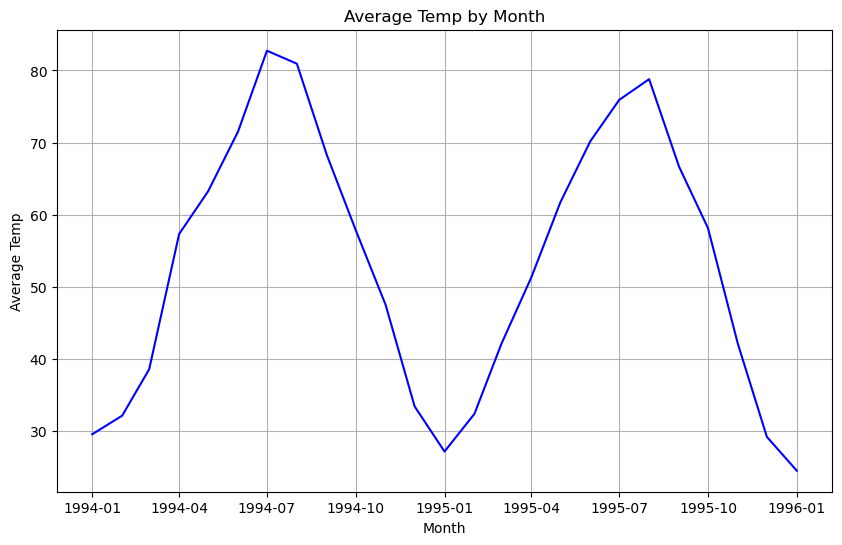

In [28]:
# Line plot of 'temp' against 'YearMonth'

line_plt = weather_data[['YearMonth', 'temp']]

# Group by 'YearMonth' and calculate average 'temp' for each month
monthly_avg_score = line_plt.groupby('YearMonth')['temp'].mean()

plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_score.index.to_timestamp(), monthly_avg_score.values, color='blue')
plt.title('Average Temp by Month')
plt.xlabel('Month')
plt.ylabel('Average Temp')
plt.grid(True)
plt.show()

I wanted to display a line plot to see the data overtime and if we can notice any seasonal variation regarding tempreatures:
* There does seem to be seasonal variations in the data.
* The highest tempreatures (peaks) are seen around the month of July (summer season).
* The lowest tempreatures (troughs) are seen during January (winter season).
* Since the line plot does show season variations, we will add it to our prediction.

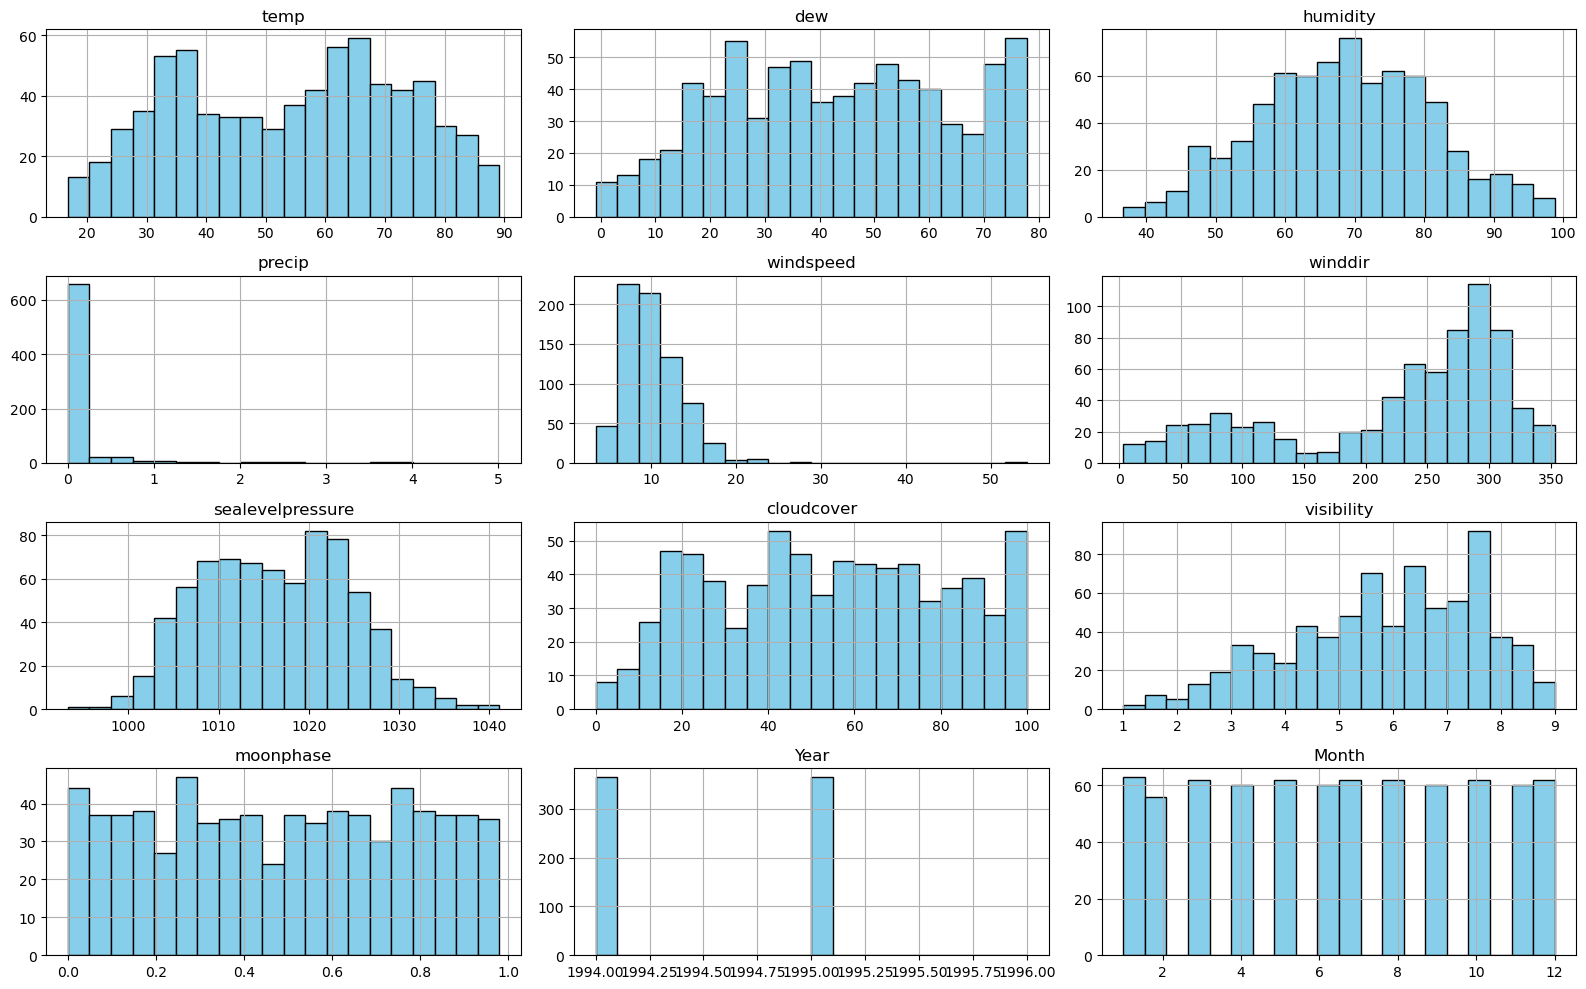

In [31]:
# Display histograms of all the numerical variables (excluding conditions)
weather_data.hist(figsize=(16, 10), bins=20, color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

These plots further emphasize the data shown in the summary statistics, but visually help us understand the distributions:
* Avg temp is bimodal and close to symmetric.
* Dewness shows a slight left skew.
* Humidity seems to be the only distribution to appears to be the most normaly distributed.
* Precip, Windspeed show positive or right skewed data.
* Winddir, Visibility appear to have negative or left skewed data.
* Cloudcover seems to be close to symmetric with a slight negative skew.
* Sealevelpressure shows a close to symmetric and normal distribution.
* Moonphase is showing close to a uniformed and symmetric distribution.
* Year obviously shows that there has been tempreature recorded in a given year.
* Month shows a uniformed distribution at around or close to 60°F

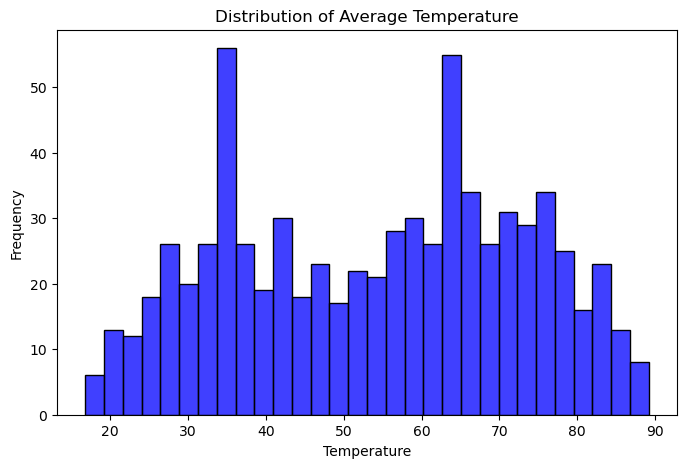

In [33]:
# Display the distribution of only Average Temprature
plt.figure(figsize=(8, 5))
sns.histplot(weather_data['temp'], bins=30, color="blue")
plt.title("Distribution of Average Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

* The distribution for average temperature seems to be close to symmetrical, confirmed by the summary statistic, however, it is bimodal with the highest frequency around 35°F and 63°F.

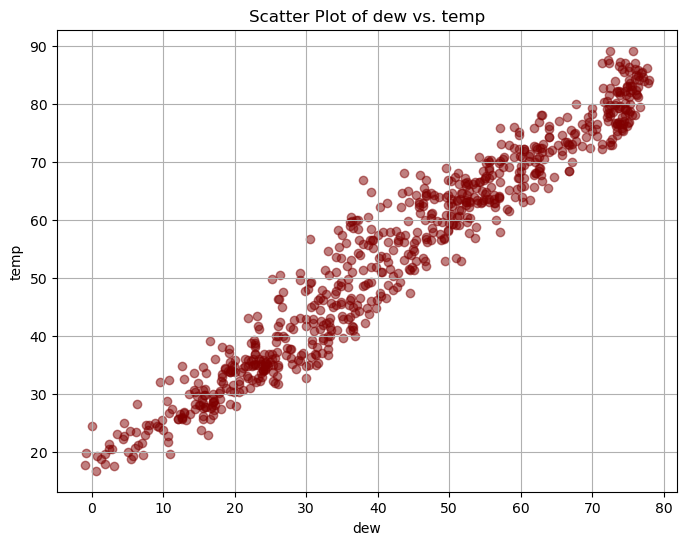

In [36]:
# Scatter plot of 'dew' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['dew'], weather_data['temp'], color='maroon', alpha=0.5)
plt.title('Scatter Plot of dew vs. temp')
plt.xlabel('dew')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatter plot shows a **positive correlation** as well as a linear relationship between the variables.

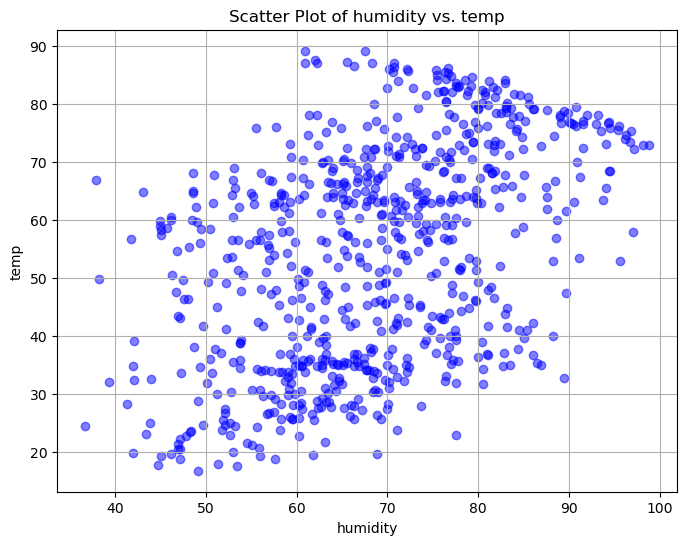

In [40]:
# Scatter plot of 'humidity' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['humidity'], weather_data['temp'], color='blue', alpha=0.5)
plt.title('Scatter Plot of humidity vs. temp')
plt.xlabel('humidity')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **positive correlation** between the variables.

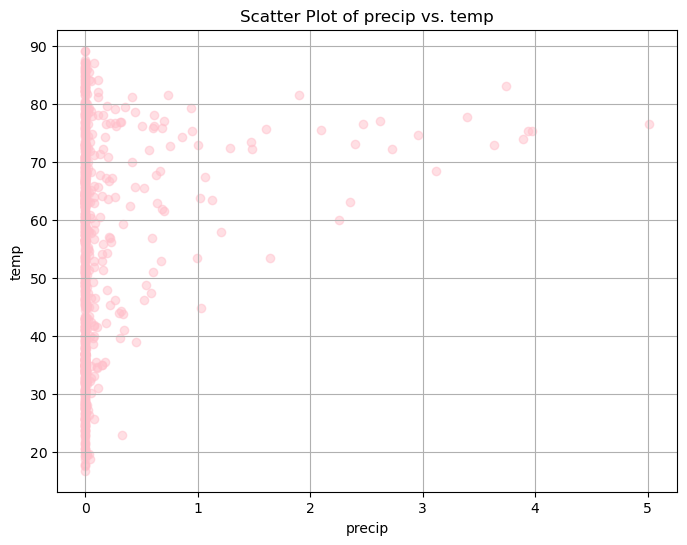

In [43]:
# Scatter plot of 'precip' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['precip'], weather_data['temp'], color='pink', alpha=0.5)
plt.title('Scatter Plot of precip vs. temp')
plt.xlabel('precip')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **weak positive** or close to **no correlation** between the variables, with temperature values spread across all precipitation levels, and most data points are clustered near "0".

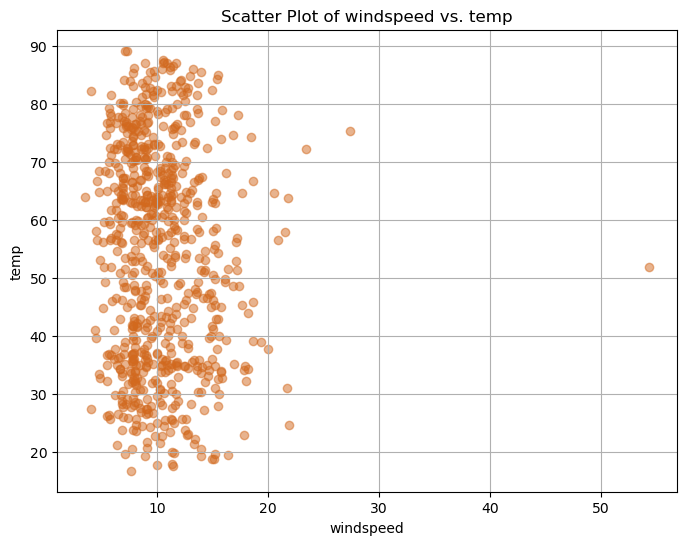

In [46]:
# Scatter plot of 'windspeed' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['windspeed'], weather_data['temp'], color='chocolate', alpha=0.5)
plt.title('Scatter Plot of windspeed vs. temp')
plt.xlabel('windspeed')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **weak negative** or close to **no correlation** between the variables, with most of the temperature values under 20 km/h.

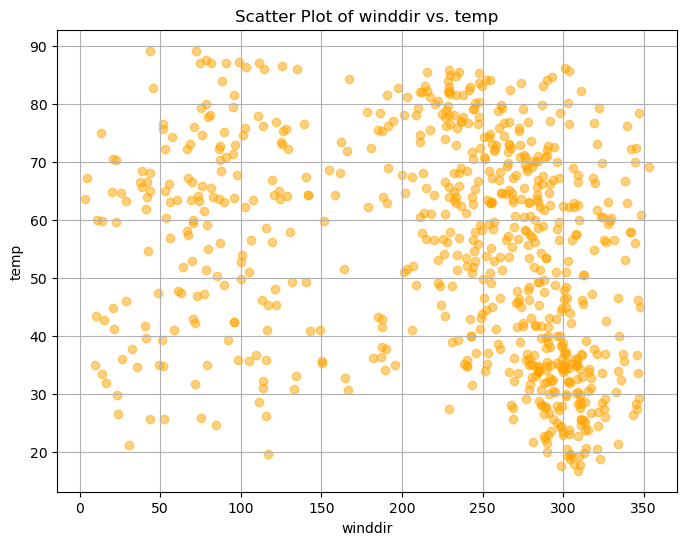

In [49]:
# Scatter plot of 'winddir' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['winddir'], weather_data['temp'], color='orange', alpha=0.5)
plt.title('Scatter Plot of winddir vs. temp')
plt.xlabel('winddir')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows **no correlation** as well as no linear relationship between the variables.

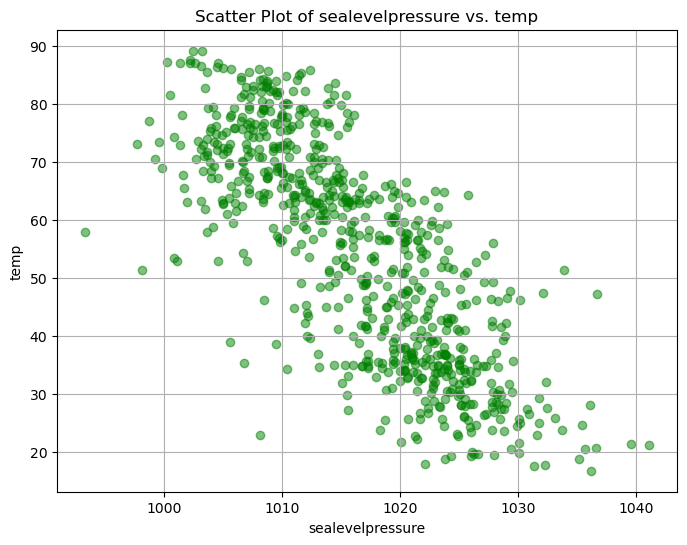

In [52]:
# Scatter plot of 'sealevelpressure' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['sealevelpressure'], weather_data['temp'], color='green', alpha=0.5)
plt.title('Scatter Plot of sealevelpressure vs. temp')
plt.xlabel('sealevelpressure')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **strong negative correlation** between thee variables.

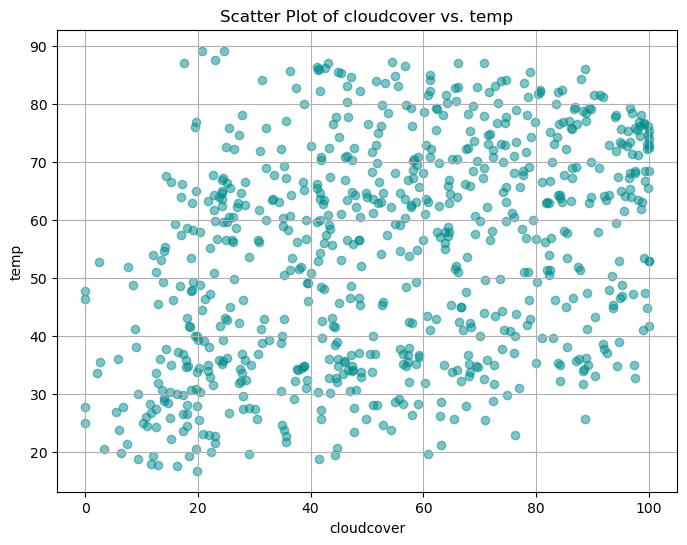

In [55]:
# Scatter plot of 'cloudcover' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['cloudcover'], weather_data['temp'], color='darkcyan', alpha=0.5)
plt.title('Scatter Plot of cloudcover vs. temp')
plt.xlabel('cloudcover')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **weak positive** close to **no correlation** between the two variables.

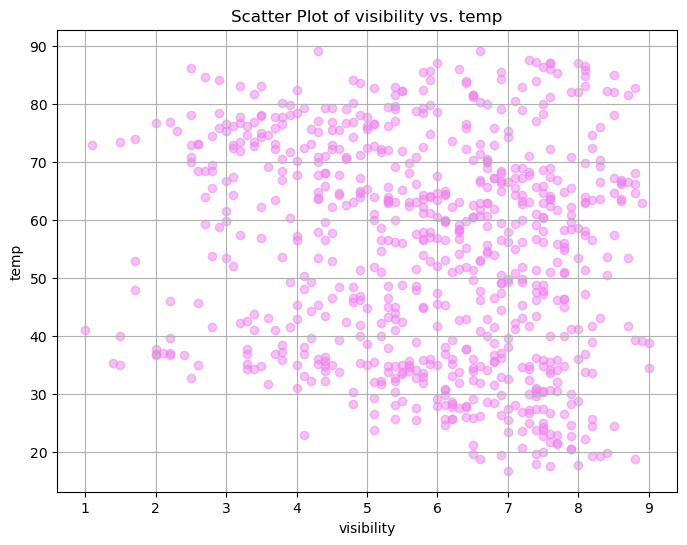

In [58]:
# Scatter plot of 'visibility' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['visibility'], weather_data['temp'], color='violet', alpha=0.5)
plt.title('Scatter Plot of visibility vs. temp')
plt.xlabel('visibility')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows a **weak negative** close to **no correlation** between the variables.

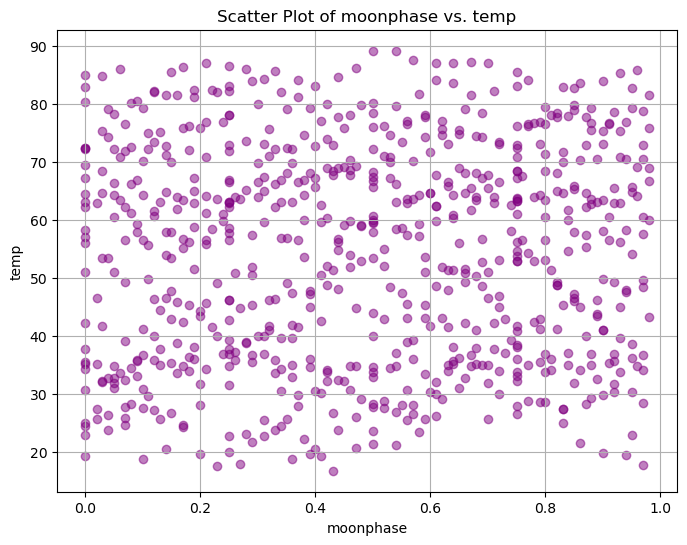

In [61]:
# Scatter plot of 'moonphase' against 'temp'
plt.figure(figsize=(8, 6))
plt.scatter(weather_data['moonphase'], weather_data['temp'], color='purple', alpha=0.5)
plt.title('Scatter Plot of moonphase vs. temp')
plt.xlabel('moonphase')
plt.ylabel('temp')
plt.grid(True)
plt.show()

* This scatterplot shows **no correlation** between the variables.

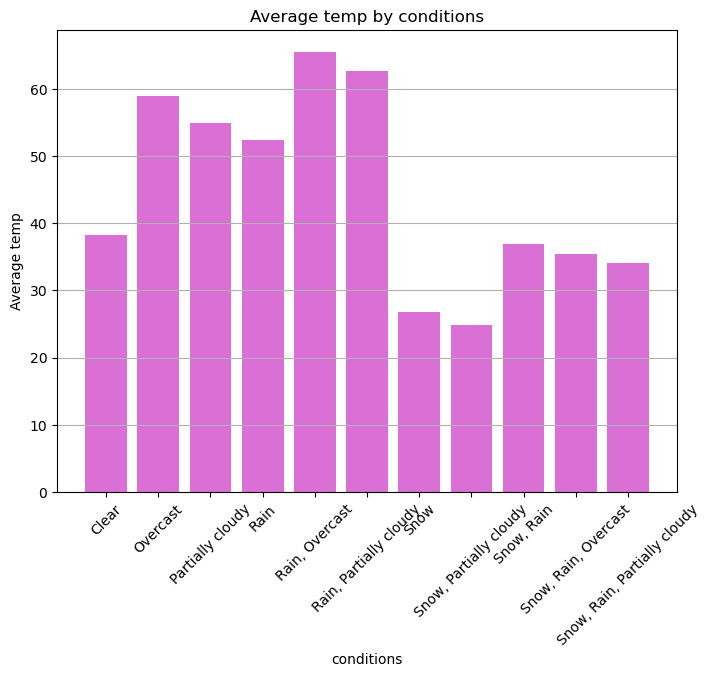

In [64]:
# Bar chart of 'temp' against 'conditions' 
temp_conditions = weather_data.groupby('conditions')['temp'].mean()

# Plot bar chart
plt.figure(figsize=(8, 6))
plt.bar(temp_conditions.index, temp_conditions.values, color='orchid')
plt.title('Average temp by conditions')
plt.xlabel('conditions')
plt.ylabel('Average temp')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

This bar graph shows the following:
* Rainy conditions tend to occur during warmer temperatures, possibly indicating rain is more frequent in warmer seasons.
* Snow-related conditions have the lowest temperatures, confirming they occur in colder months.
* Overcast conditions can be warm, suggesting cloud coverage may trap heat in certain cases.
* Clear weather is not necessarily the warmest, as it can happen in both cold and warm conditions.

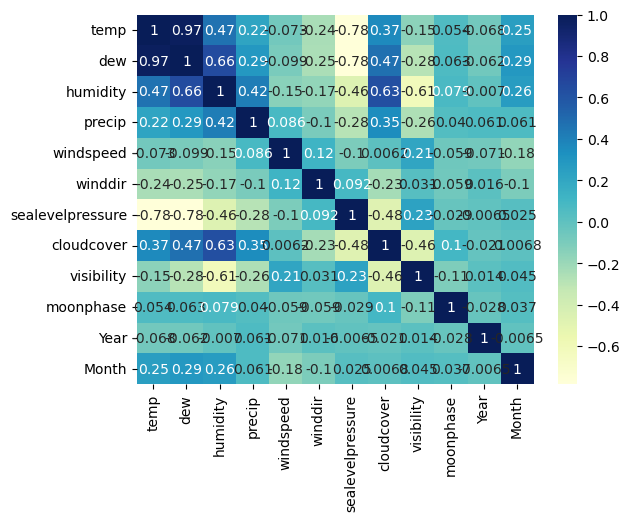

In [67]:
# Corr heatmap only for numeric values (excluding conditions)
numeric_weather_data = weather_data.select_dtypes(include=['number'])

dataplot = sns.heatmap(numeric_weather_data.corr(), cmap="YlGnBu", annot=True)
plt.show()

* Based on this corrplot I will be excluding Dew Point from my predictive models since it is highly correlated with my outcome variable (Average Temperature).

# Feature Engineering

In [71]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

In [73]:
# Apply Label Encoding to 'conditions'
encoder = LabelEncoder()
weather_data['conditions_encoded'] = encoder.fit_transform(weather_data['conditions'])

# Drop original column and keep new 'conditions_encoded'
weather_data.drop(columns=['conditions'], inplace=True)

* I decided to use label encoder to convert conditions to numerical values in order to apply it to my predictive models of choice.

In [76]:
# Check null percentage
null_percentage = (weather_data.isnull().sum() / len(weather_data)) * 100

print("Null Percentage by Column:")
print(null_percentage)

Null Percentage by Column:
temp                  0.0
dew                   0.0
humidity              0.0
precip                0.0
windspeed             0.0
winddir               0.0
sealevelpressure      0.0
cloudcover            0.0
visibility            0.0
moonphase             0.0
Year                  0.0
Month                 0.0
YearMonth             0.0
conditions_encoded    0.0
dtype: float64


* I want to observe if I have any null values remain, but since they do not, I can continue and do not need to apply the mean to fill missing values.

In [87]:
# Check for missing values
print(weather_data.isnull().sum())

temp                  0
dew                   0
humidity              0
precip                0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility            0
moonphase             0
Year                  0
Month                 0
YearMonth             0
conditions_encoded    0
dtype: int64


* I wanted to double check for missing values, but again since I have none, I can proceed.

In [116]:
# Define target (Y) and feature variables (X)
X = weather_data[['humidity', 'precip', 'windspeed', 'winddir', 
                  'sealevelpressure', 'cloudcover', 'visibility', 'moonphase', 'conditions_encoded', 'Year', 'Month',]]
y = weather_data['temp']

# Split the data into training & testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
scaler = StandardScaler()

# Scale both training and testing data
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test) 

* I decided to apply standard scaler to my data in order to transform the data, since I will be applying it to a Linear Regression, SVM and Lasso.
* I will be running a Random Forest as well, and I do not need to scale the data for it, but due to the other predicitve models I will be using, I felt it was necessary.
* Additionally, I found that using 'YearMonth' as a feature variable would not work and had to use splitted columns 'Year' & 'Month'.

In [121]:
# Check for skew in X
skewness_values = X.apply(skew, axis=0)

# Display skewness values
print(skewness_values)

humidity              0.004330
precip                5.666398
windspeed             3.003395
winddir              -0.891412
sealevelpressure      0.071850
cloudcover            0.006919
visibility           -0.465488
moonphase            -0.008090
conditions_encoded    1.279916
Year                  0.024093
Month                -0.009452
dtype: float64


I wanted to check for sknewness and see if the data must be required to be transformed if the value is greater than 1 or less than -1:
* Precip is at 5.66 skewness which is greater than 1, which must be transformed.
* Windspeed is at 3.00 skewness which is greater than 1, which must be transformed.
* Conditions_encoded is at 1.28 skewness which is greater than 1, which must be transformed.

In [124]:
# Create a copy of X just in case, to avoid modifying the original dataset
X = X.copy()

# Make sure that the column is float before applying log or else it won't work
X['conditions_encoded'] = X['conditions_encoded'].astype(float)

# Apply log transformation safely using .loc[]
X.loc[:, 'precip'] = np.log1p(X['precip'])  
X.loc[:, 'windspeed'] = np.log1p(X['windspeed'])
X.loc[:, 'conditions_encoded'] = np.log1p(X['conditions_encoded'])

* I created a copy of my X values as previously I did not and it did not work, in doing so I made sure that my original dataset was not modified.
* I decided to log the variables that needed transformation since they all were greater than 1 specifically.
* Since those specific variables are highly right skewed, by logging them, the values become compressed making them more normal.
* A log transformation is used to reduce skewness and normalize highly skewed data, and if my values were negative, the log may distort the data.

# Model Building

I already split the data previously to efficiently execute scaling and skew transformation. Using that train and test set, we will begin testing models of the following:
* Linear Regression - because if temp has a linear relationship with features, this model can be a good fit.
* Random Forest - because it can capture complex relationships between weather variables and temperature, also selecting the most important features.
* Support Vector Machine (SVM) - because it would be useful if temperature does not have a simple linear relationship with features like humidity, wind speed, or cloud cover.
* Lasso Regression - because it prevents overfitting, and can help when the dataset has many weak predictors. Also, this model keeps only the most significant weather factors.

I wanted to test these 4 models we learned in class, with my prediction being that Random Forest will be the best model to use, based on the performance evaluation metrics that will be measured:
* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R-Squared Score (R-Squared)

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso

**Linear Regression**

In [139]:
# Train and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate the metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print the results
print("- Linear Regression Performance:")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

- Linear Regression Performance:
MAE: 7.621072178705933
MSE: 94.8262265854958
RMSE: 9.737875876467918
R2 Score: 0.7269009347846422


**Random Forest**

In [141]:
# Train and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Calculate the metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Print the results
print("- Random Forest Performance:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

- Random Forest Performance:
MAE: 3.3329659863945555
MSE: 18.614391673469374
RMSE: 4.314439902637349
R2 Score: 0.9463906437214007


**SVM**

In [143]:
# Train and fit the model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate the metrics
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

# Print the results
print("- SVM Regression Performance:")
print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("RMSE:", rmse_lr)
print("R2 Score:", rmse_svm)

- SVM Regression Performance:
MAE: 9.122681931482516
MSE: 122.23813516170469
RMSE: 9.737875876467918
R2 Score: 11.056135634194467


**Lasso**

In [145]:
# Train and fit the model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate the metrics
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print the results
print("- Lasso Regression Performance:")
print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2 Score:", r2_lasso)

- Lasso Regression Performance:
MAE: 7.6290353493963154
MSE: 95.35051690632079
RMSE: 9.764758927199422
R2 Score: 0.72539098124463


# Model Evaluation & Selection

In [147]:
# Model results to compare metrics 
print("Results (Linear Regression):", mae_lr, mse_lr, rmse_lr, r2_lr)
print("Results (Random Forest):", mae_rf, mse_rf, rmse_rf, r2_rf)
print("Results (SVM):", mae_svm, mse_svm, rmse_svm, r2_svm)
print("Results (Lasso Regression):", mae_lasso, mse_lasso, rmse_lasso, r2_lasso)

Results (Linear Regression): 7.621072178705933 94.8262265854958 9.737875876467918 0.7269009347846422
Results (Random Forest): 3.3329659863945555 18.614391673469374 4.314439902637349 0.9463906437214007
Results (SVM): 9.122681931482516 122.23813516170469 11.056135634194467 0.6479547731846977
Results (Lasso Regression): 7.6290353493963154 95.35051690632079 9.764758927199422 0.72539098124463


After running all four models, and based on the results of the evaluation metrics we get, it seems that the best model to use is **Random Forest**:
* Lowest MAE (3.33) - Most accurate predictions.
* Lowest MSE (18.61) - Least overall error.
* Lowest RMSE (4.31) - Predictions deviate the least from actual values.
* Highest R² Score (0.95) - Best at explaining variance in temperature.

# Model Tuning

In [151]:
from sklearn.model_selection import GridSearchCV

In [153]:
# Model Tuning for the best selected model: Random Forest

# Define parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
 }

# Random forest regressor
rf_model_g = RandomForestRegressor(random_state=44)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model_g, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Perform grid search and fit the data
grid_search.fit(X_train, y_train)

# Get the best model and best parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Print best parameters
print("Best parameters:", best_params)

# Make predictions on test data using the best model
y_pred_best_rf = best_rf_model.predict(X_test)

# Calculate the metrics for the best model
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

# Print the results
print("- Model Tuned Random Forest Metrics:")
print("MAE:", mae_best_rf)
print("MSE:", mse_best_rf)
print("RMSE:", rmse_best_rf)
print("R2 Score:", r2_best_rf)

Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
- Model Tuned Random Forest Metrics:
MAE: 3.348289115646266
MSE: 18.836479457483048
RMSE: 4.340101318803865
R2 Score: 0.9457510319980006


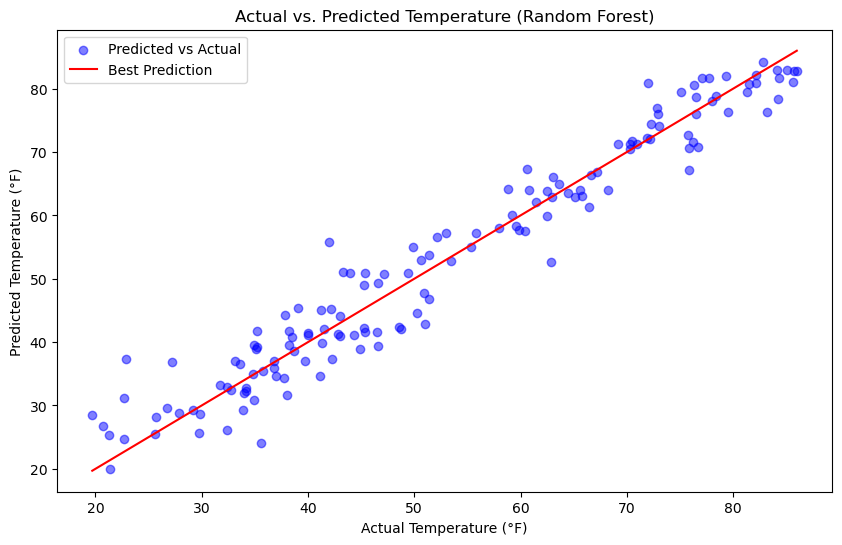

In [155]:
# Scatter plot for Actual vs. Predicted values using Random Forest as Best Model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best_rf, color='blue', alpha=0.5, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label="Best Prediction")
plt.xlabel("Actual Temperature (°F)")
plt.ylabel("Predicted Temperature (°F)")
plt.title("Actual vs. Predicted Temperature (Random Forest)")
plt.legend()
plt.show()

# Conclusion

**Model Interpretation:**
To conclude, my study aimed to predict average tempreature in Seoul, Korea using multiple predictive regression models including Linear Regression, Random Forest, Support Vector Machine (SVM), and Lasso Regression. The results showed that Random Forest performed better than the other models achieving the lowest Mean Absolute Error (MAE), lowest Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) while attaining the highest R² score. This suggests that Random Forest is the most suitable model for capturing the complex relationships between temperature and weather variables such as humidity, wind speed, sea-level pressure, and cloud cover.

It is important to note that Linear Regression and Lasso Regression showed similar performance, which may indicate that the variables chosen may not have excessive irrelevant features, as Lasso typically removes unimportant predictors. However, both models had higher errors compared to Random Forest, which could be because they assume linear relationships, and it may not fully capture the non-linear interactions within the data. SVM, performed the worst, possibly due to the fact that is is sensitive to feature scaling.

**Features:**
Upon analyzing the data, sea level pressure and humidity show to have the strongest impact on temperature,  while wind speed and wind direction had a weaker correlation. It is extremely important to note that seasonal patterns were captured, which indicates that the average temperature variations follow seasonal trends. These results emphasize how crucial it is to choose the correct variables and transformations when creating weather prediction models.

**Improvements:**
To further improve this project, there is much I can do. I could remove, if any, outliers. If the dataset could include temperatures at different hours, that could identify further patterns. Additionally, there are other models that can be used such as Neural Networks. I should've and could have also plottted the residuals to check for model bias which I realize now I did not include. Additionally, cross validating the data which helps ensure the model works well by testing it on different subsets of the dataset.

**Process:**
I found this project to be a bit difficult as I ran into some errors regarding the datetime and had to figure out how to break the date time into Year, Month and also assigning both into one column like 'YearMonth" in order to observe the data overtime. I also had issues running my models as first because I did not split the data correctly, and had to review the 80/20 test/train split in order to run my models most efficeintly. When I first ran my project and models, I found Linear Regression to be the best, and based on what we learned in class, I knew I did something wrong as Random Forest should work best, unless the data has linear relationships. I found that this was because I split the data incorrrectly. After doing the 80/20, my predcition that Random Forest would be best turned out to be true. Regarding data cleaning, I dropped a numerous amount of columns and I am still not sure if all of those variables were best to be dropped. For the model tuning, I decied to keep the n_estimators (50, 100, 200), max_depth (None, 10, 20), and min_samples_split (2, 5, 10) to run my model faster (up to 5 minutes), I am not sure if this was the most efficient method. I think this would be best if the dataset was a lot larger. Overall, I am happy with my results and hope they are efficent and accurate to predict average tempreatures. Should this be the case, I would want to run another project using SF data, which has fewer columns and see what model works best to predict the average tempratures in SF.

# Refrences
* NASA. (2025). Temperatures Rising: NASA Confirms 2024 Warmest Year on Record. https://www.nasa.gov/news-release/temperatures-rising-nasa-confirms-2024-warmest-year-on-record/
* NOAA National Centers for Environmental Information. (2024). Monthly Global Climate Report for Annual 2023. https://www.ncei.noaa.gov/access/monitoring/monthly-report/global/202313. 